In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.weightstats import ttest_ind
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.stats.api as sms
import statsmodels.api as sm
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

In [33]:
collocated_calibrated_data = pd.read_csv("calibrated datasets/C DPP sensors calibrated.csv")
dem_data = pd.read_csv("cleaned DEM data/dem_cleaned.csv")

In [34]:
collocated_calibrated_data["datetime_utc"] = pd.to_datetime(collocated_calibrated_data["datetime_utc"])

dem_data["datetime_utc"] = pd.to_datetime(dem_data["datetime_utc"])

sensor01 = (collocated_calibrated_data[["datetime_utc", "Sensor01"]].rename(columns={"Sensor01": "sensor01_no2"}))

dem_no2 = (dem_data[["datetime_utc", "no2"]].rename(columns={"no2": "dem_no2"})
)

df_compare = pd.merge(
    dem_no2,
    sensor01,
    on="datetime_utc",
    how="inner"
)

df_compare_clean = df_compare.dropna(subset=["dem_no2", "sensor01_no2"])

print(df_compare.shape)
print(df_compare_clean.shape)

df_compare_clean.head()

(5616, 3)
(5125, 3)


,datetime_utc,dem_no2,sensor01_no2
0,2025-10-09 22:00:00,3.3,7.96
1,2025-10-09 23:00:00,7.8,12.42
2,2025-10-10 00:00:00,16.5,17.04
3,2025-10-10 01:00:00,15.8,18.74
4,2025-10-10 02:00:00,15.7,20.62


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


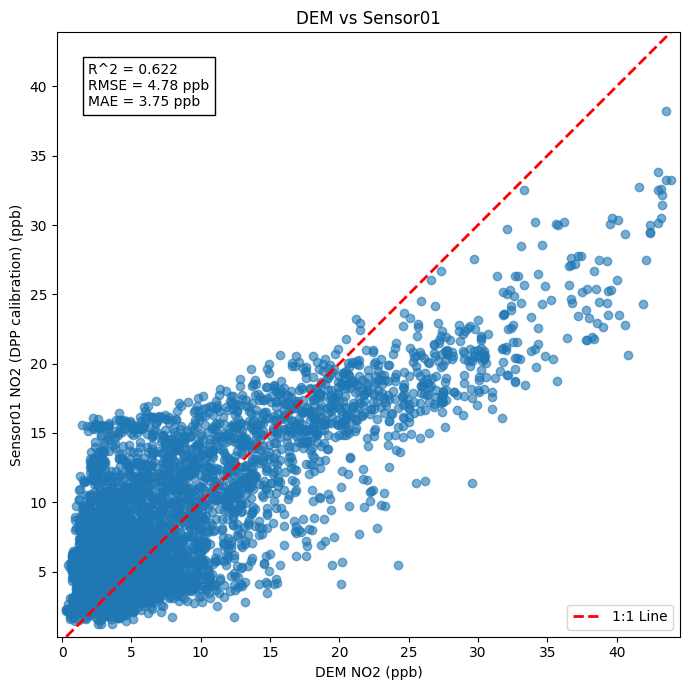

In [35]:
x = df_compare_clean["dem_no2"]
y = df_compare_clean["sensor01_no2"]

r2 = r2_score(x, y)
rmse = mean_squared_error(x, y) ** 0.5
mae = mean_absolute_error(x, y)

plt.figure(figsize=(7,7))

plt.scatter(x, y, alpha=0.6)

min_val = min(x.min(), y.min())
max_val = max(x.max(), y.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    linewidth=2,
    label="1:1 Line"
)

plt.xlabel("DEM NO2 (ppb)")
plt.ylabel("Sensor01 NO2 (DPP calibration) (ppb)")
plt.title("DEM vs Sensor01")

plt.text(
    0.05,
    0.95,
    f"R^2 = {r2:.3f}\nRMSE = {rmse:.2f} ppb\nMAE = {mae:.2f} ppb",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(facecolor="white")
)

plt.axis("equal")
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.legend()
plt.tight_layout()
plt.show()

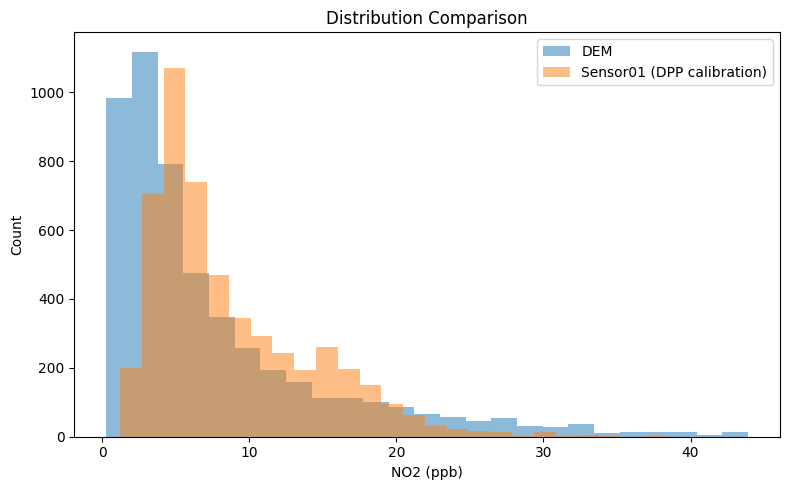

In [36]:
plt.figure(figsize=(8,5))

plt.hist(
    df_compare_clean["dem_no2"],
    bins=25,
    alpha=0.5,
    label="DEM"
)

plt.hist(
    df_compare_clean["sensor01_no2"],
    bins=25,
    alpha=0.5,
    label="Sensor01 (DPP calibration)"
)

plt.xlabel("NO2 (ppb)")
plt.ylabel("Count")
plt.title("Distribution Comparison")
plt.legend()

plt.tight_layout()
plt.show()

/var/folders/cv/16s476bd69z2kjqnmm06ls5c0000gn/T/ipykernel_18577/3268745264.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


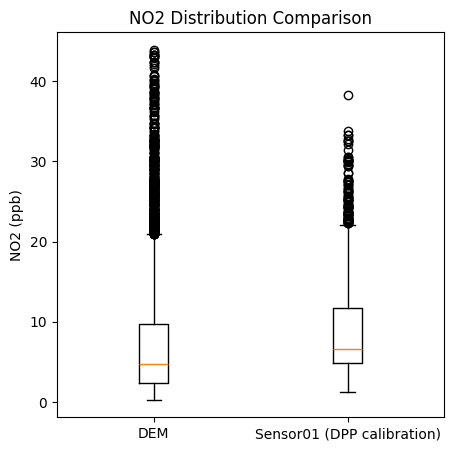

In [37]:
plt.figure(figsize=(5,5))

plt.boxplot([
    df_compare_clean["dem_no2"],
    df_compare_clean["sensor01_no2"]
],
labels=["DEM", "Sensor01 (DPP calibration)"])

plt.ylabel("NO2 (ppb)")
plt.title("NO2 Distribution Comparison")

plt.show()

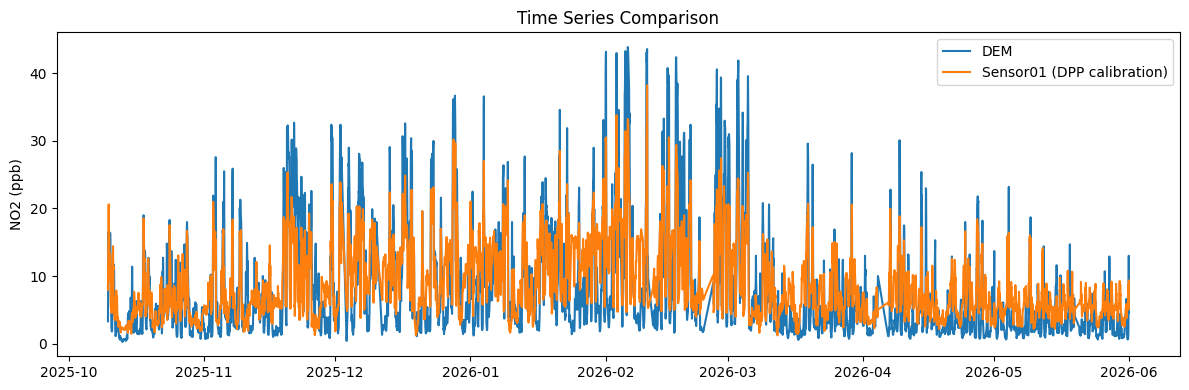

In [38]:
plt.figure(figsize=(12,4))

plt.plot(
    df_compare_clean["datetime_utc"],
    df_compare_clean["dem_no2"],
    label="DEM"
)

plt.plot(
    df_compare_clean["datetime_utc"],
    df_compare_clean["sensor01_no2"],
    label="Sensor01 (DPP calibration)"
)

plt.ylabel("NO2 (ppb)")
plt.title("Time Series Comparison")
plt.legend()

plt.tight_layout()
plt.show()

/var/folders/cv/16s476bd69z2kjqnmm06ls5c0000gn/T/ipykernel_18577/1200907057.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_compare_clean["residual"] = df_compare_clean["sensor01_no2"] - df_compare_clean["dem_no2"]


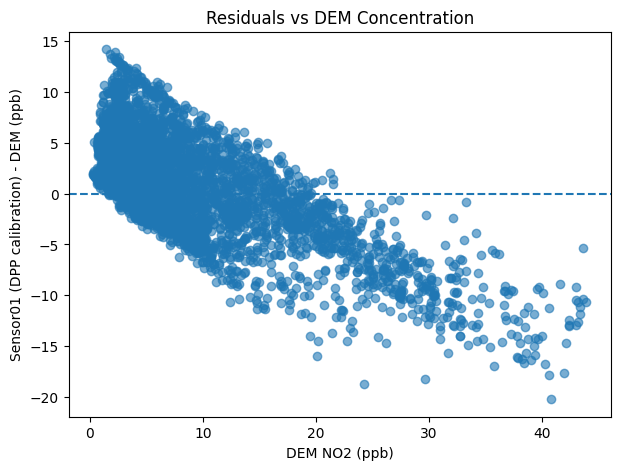

In [39]:
df_compare_clean["residual"] = df_compare_clean["sensor01_no2"] - df_compare_clean["dem_no2"]

plt.figure(figsize=(7,5))

plt.scatter(
    df_compare_clean["dem_no2"],
    df_compare_clean["residual"],
    alpha=0.6
)

plt.axhline(0, linestyle="--")

plt.xlabel("DEM NO2 (ppb)")
plt.ylabel("Sensor01 (DPP calibration) - DEM (ppb)")
plt.title("Residuals vs DEM Concentration")

plt.show()